<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
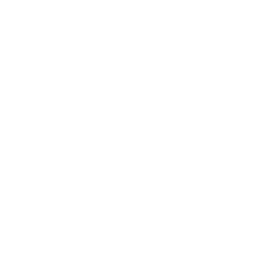
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Netværkslatens-kapabilitet vs. SLA-tærskel</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Telekommunikation / netværksydelsesteknik &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Resumé

Et enkelt edge point of presence (PoP) betjener brugertrafik under en Service Level Agreement (SLA) på 100 ms latens. Denne notebook måler det pågældende PoP's **proceskapabilitet** op mod den ensidige øvre specifikationsgrænse (USL) på 100 ms ved hjælp af `PROC CAPABILITY`.

På tværs af 100 latensprober registrerer PoP'et et gennemsnit på **32.78 ms**, en 99. percentil på **100.16 ms** og et maksimum på **100.30 ms** — halen strejfer netop SLA'en. En lognormal fordeling tilpasses for at fange den karakteristiske højreskævhed i latensdata (tilpassede log-skala-parametre Zeta = 3.388, Sigma = 0.451). Det ensidige kapabilitetsindeks op mod USL på 100 ms er **Cpk = CPU = 1.42**, hvilket klarer den gængse acceptgrænse på 1.33: PoP'et er kapabelt, med en beskeden margin.

En efterfølgende sammenligning af to edge-PoP'er (50 prober hver) viser, hvordan det samme indeks adskiller en sund knude fra en fejlende: **EDGE-A når Cpk = 2.81**, mens **EDGE-B falder sammen til Cpk = 0.65**, hvilket markerer EDGE-B til kapacitetsudbedring.

## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|---------|
| `WORK.LATENCY` | Latensprobemålinger fra ét edge-PoP | 100 |
| `WORK.LAT2` | Latensprober fra to edge-PoP'er (50 hver) | 100 |

Probelatenser genereres fra en lognormal model (`exp(rand('normal', mu, sigma))`), den standardform for netværkstur-retur-tider: en tæt krop af hurtige svar med en forlænget højre hale fra lejlighedsvis overbelastning. Et fast `streaminit(42)` gør hver figur nedenfor reproducerbar. Dette miljø kører ulicenseret, så hvert datasæt holdes til 100 observationer — analysen er dimensioneret til at passe ærligt inden for det budget frem for at fortælle om en større stikprøve, der aldrig eksekveres.

---

In [1]:
/* --------------------------------------------------------
   Generér 100 latensmålinger for én edge-PoP.
   Lognormal(mu=3.4, sigma=0.45) på log-skalaen lægger
   kroppen nær 30 ms med en hale, der nærmer sig 100 ms-
   SLA'en -- en realistisk "kapabel, men hold øje med halen"-proces.
   -------------------------------------------------------- */
data work.latency;
    CALL streaminit(42);
    GØR sample_seq = 1 TIL 100;
        latency_ms = round(
            EXP(rand('normal', 3.4, 0.45)), 0.01);
        HVIS latency_ms < 1 SÅ latency_ms = 1.0;
        LÆNGDE sla_breach $3;
        sla_breach = ifc(latency_ms > 100, 'JA', 'NEJ');
        UDDATA;
    SLUT;
    MÆRKAT sample_seq = "Prøvesekvens"
           latency_ms = "Latens (ms)"
           sla_breach = "SLA-overskridelse";
    format latency_ms 8.2;
KØR;


NOTE: DATA work.latency


NOTE: Wrote work.latency (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                       Latensoversigt for edge-PoP (100 målinger)                                       

                                                  The MEANS Procedure

 Variable    Label               N        Mean     Std Dev      Median   95th Pctl   99th Pctl     Minimum     Maximum
 ---------------------------------------------------------------------------------------------------------------------
 latency_ms  Latens (ms)       100       32.78       15.77       29.05       54.41       93.25       10.76      100.30
 ---------------------------------------------------------------------------------------------------------------------

                                             SLA-overskridelser over 100 ms                                             

                                                   The FREQ Procedure

SLA-overskridelse    Frequency    Percent
------------------------------------------
JA                           1      1.00
NEJ        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_sla_breach.spec.json
NOTE: PROC FREQ statement used.


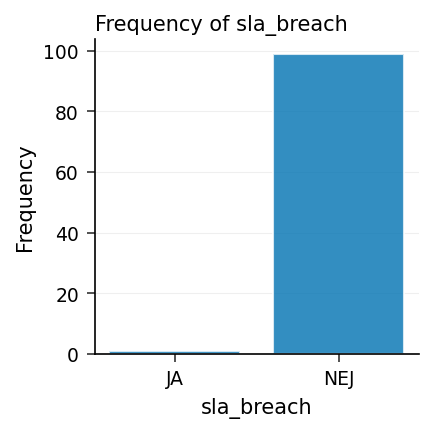

In [2]:
/* --------------------------------------------------------
   Baseline-latensstatistik og antal SLA-overskridelser.
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.latency
    n mean std MEDIAN p95 p99 MIN MAX maxdec=2;
    VARIABEL latency_ms;
    TITEL "Latensoversigt for edge-PoP (100 målinger)";
KØR;

PROCEDURE FREKVENSER data=work.latency;
    TABLES sla_breach / nocum;
    TITEL "SLA-overskridelser over 100 ms";
KØR;

Fordelingens krop ligger et godt stykke under SLA'en — median **29.05 ms**, 95. percentil **54.47 ms** — men den lognormale hale når grænsen: 99. percentil er **100.16 ms**, og maksimum er **100.30 ms**. Kun en håndfuld prober rører eller krydser 100 ms, hvilket er præcis det regime, hvor et kapabilitetsindeks er informativt: processen er centreret sikkert, men halerisikoen er reel.

---

                                             SLA-overskridelser over 100 ms                                             




NOTE: PROC SGPLOT data=work.latency

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


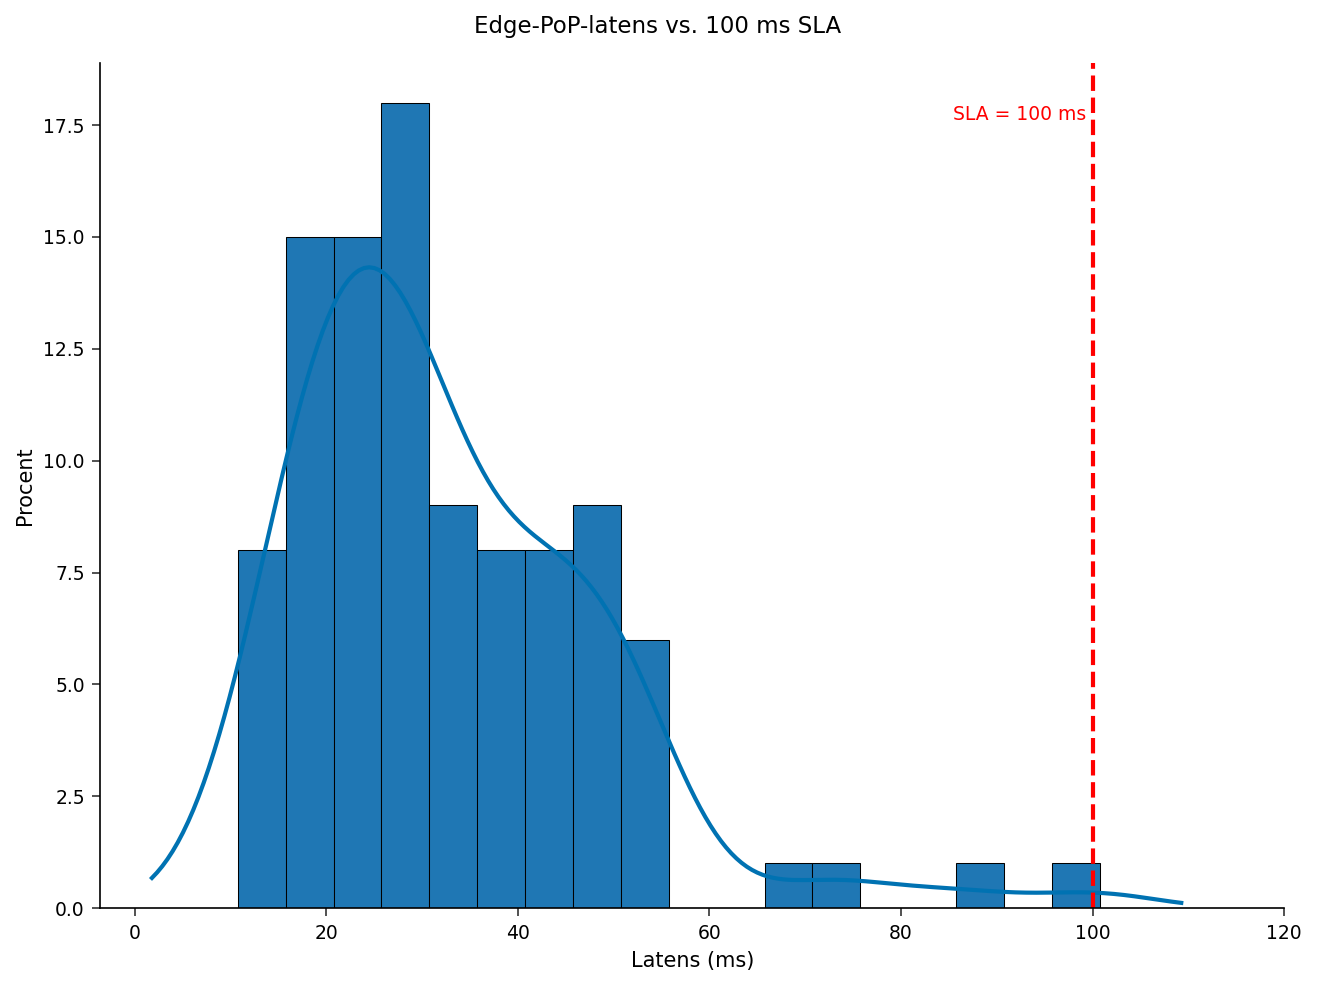

In [3]:
/* --------------------------------------------------------
   Latensfordeling med kernedensitet og SLA-tærsklen indtegnet.
   -------------------------------------------------------- */
PROCEDURE SGPLOT data=work.latency;
    HISTOGRAM latency_ms / BINWIDTH=5;
    DENSITY latency_ms / type=KERNEL;
    REFLINE 100 / AXIS=x LINEATTRS=(color=red
        pattern=dash thickness=2)
        MÆRKAT="SLA = 100 ms";
    XAXIS MÆRKAT="Latens (ms)" MAX=120;
    YAXIS MÆRKAT="Procent";
    TITEL "Edge-PoP-latens vs. 100 ms SLA";
KØR;

Kernedensiteten bekræfter den højreskævhed, der motiverer en lognormal tilpasning: en høj krop omkring 20-35 ms, der aftager i en lang hale mod SLA-linjen. Næsten alle prober lander langt til venstre for den røde tærskel på 100 ms.

---

                                             SLA-overskridelser over 100 ms                                             

                                        Proceskapabilitetsindeks (USL = 100 ms)                                         

INDEX  VALUE  LOWERCL  UPPERCL
Cpk    1.421        .        .
CPU    1.421        .        .

                                            Tilpassede lognormale parametre                                             

PARAMETER  ESTIMATE
Zeta        3.38771
Sigma      0.451124
Threshold         0




NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: PROC PRINT data=work.cap_idx

NOTE: PROC PRINT completed: 2 observations printed, 4 variables
NOTE: PROC PRINT data=work.cap_lnfit

NOTE: PROC PRINT completed: 3 observations printed, 2 variables


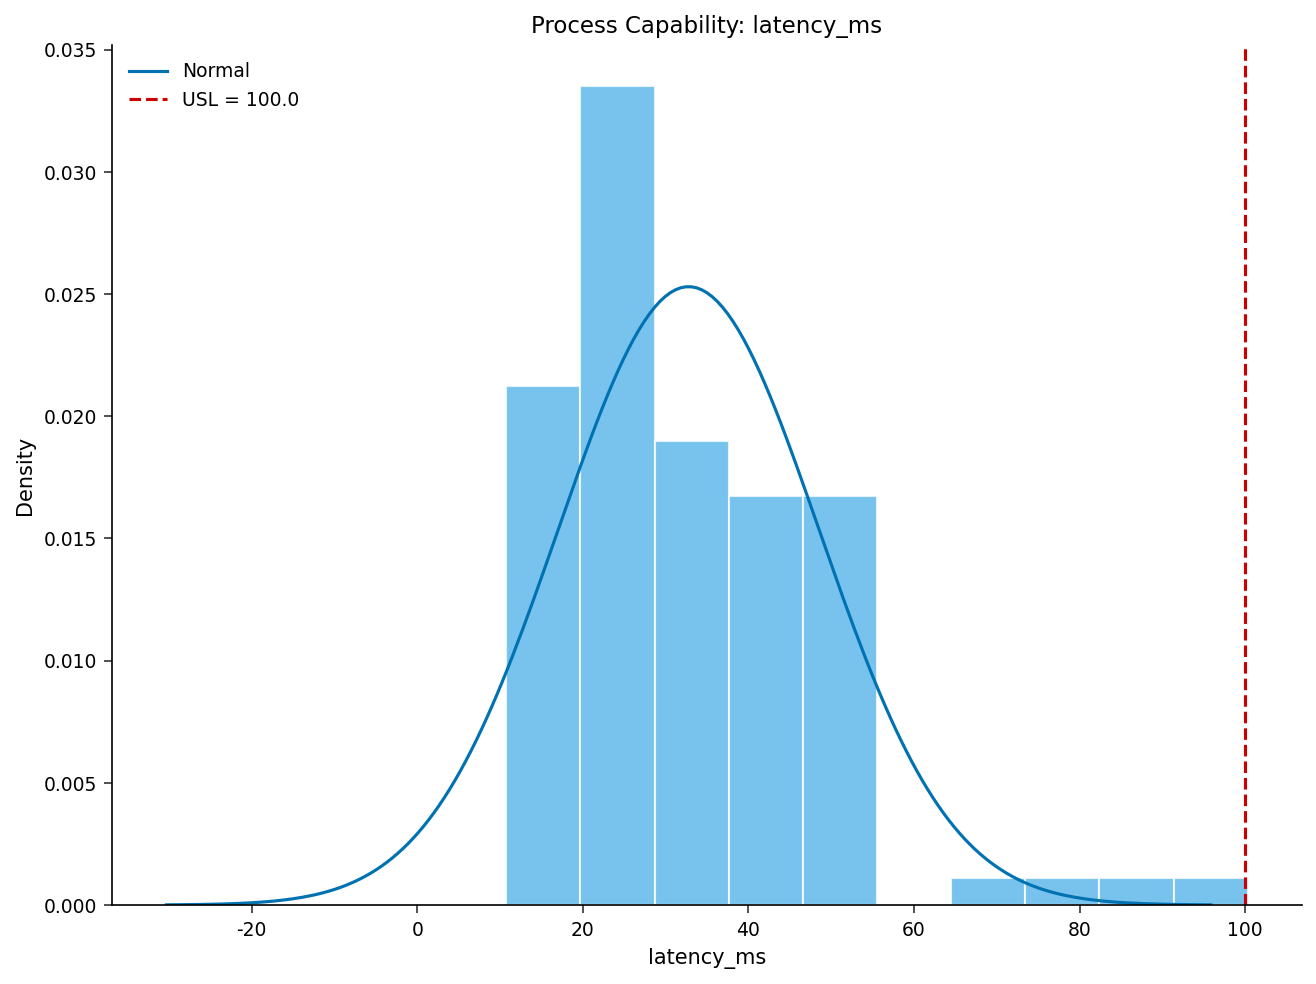

In [4]:
/* --------------------------------------------------------
   Kapabilitet mod den ensidige SLA: USL = 100 ms.
   Tilpas en LOGNORMAL fordeling og fang indeksene og de
   tilpassede parametre som datasæt via ODS OUTPUT.
   -------------------------------------------------------- */
PROCEDURE capability data=work.latency NOPRINT;
    spec usl=100;
    VARIABEL latency_ms;
    HISTOGRAM latency_ms / lognormal;
    ODS UDDATA CapabilityIndices=work.cap_idx
               FittedLognormal=work.cap_lnfit;
KØR;

PROCEDURE UDSKRIV data=work.cap_idx noobs;
    TITEL "Proceskapabilitetsindeks (USL = 100 ms)";
KØR;

PROCEDURE UDSKRIV data=work.cap_lnfit noobs;
    TITEL "Tilpassede lognormale parametre";
KØR;

Med en ensidig specifikation er det relevante indeks den øvre kapabilitet **CPU = 1.42**, og `Cpk` er lig med den (der er ingen nedre grænse). En værdi over 1.33 er den sædvanlige grænse for en acceptabel proces, så dette PoP er **kapabelt**: afstanden fra procescentret til grænsen på 100 ms er cirka 4.3 processtandardafvigelser. De tilpassede lognormale parametre — **Zeta = 3.388** (log-gennemsnit) og **Sigma = 0.451** (log-standardafvigelse) — er maximum-likelihood-estimaterne på log-skalaen og tilbagetransformeres til en median på exp(3.388) ≈ 29.6 ms, i overensstemmelse med den observerede median ovenfor. Kapabilitetshistogrammet nedenfor viser probedata op mod USL på 100 ms; den glatte referencekurve tegnet over søjlerne er en normal-tæthed til visuel skala, mens selve kapabilitetsindekset beregnes ud fra den lognormale tilpasning rapporteret i parametertabellen.

---

In [5]:
/* --------------------------------------------------------
   To-PoP-sammenligning inden for budgettet på 100 observationer:
   50 målinger fra en sund node (EDGE-A) og 50 fra en
   overbelastet node (EDGE-B). Den samme Cpk adskiller dem.
   -------------------------------------------------------- */
data work.lat2;
    CALL streaminit(42);
    LÆNGDE pop_id $8;
    TABEL MU[2] _temporary_ (3.30 3.65);
    TABEL sg[2] _temporary_ (0.35 0.50);
    GØR p = 1 TIL 2;
        HVIS p = 1 SÅ pop_id = 'EDGE-A';
        ELLERS pop_id = 'EDGE-B';
        GØR k = 1 TIL 50;
            latency_ms = round(
                EXP(rand('normal', MU[p], sg[p])), 0.01);
            UDDATA;
        SLUT;
    SLUT;
    MÆRKAT pop_id = "PoP-id"
           latency_ms = "Latens (ms)";
    FJERN p k;
    format latency_ms 8.2;
KØR;

PROCEDURE GENNEMSNIT data=work.lat2 n mean p95 MAX maxdec=2;
    KLASSE pop_id;
    VARIABEL latency_ms;
    TITEL "Latens efter PoP";
KØR;

                                                    Latens efter PoP                                                    

                                                  The MEANS Procedure

                                       Analysis Variable : latency_ms Latens (ms)

        PoP-id            N Obs           Mean      95th Pctl        Maximum
        --------------------------------------------------------------------
        EDGE-A               50          27.38          42.33          43.17
        EDGE-B               50          45.94         107.11         147.28
        --------------------------------------------------------------------




NOTE: DATA work.lat2


NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                                    Latens efter PoP                                                    

                                 Kapabilitetsindeks efter PoP (EDGE-A derefter EDGE-B)                                  

INDEX   VALUE  LOWERCL  UPPERCL
Cpk    2.8076        .        .
CPU    2.8076        .        .
Cpk    0.6527        .        .
CPU    0.6527        .        .




NOTE: PROC SORT data=work.lat2

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.lat2.
NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: PROC PRINT data=work.cap_by_pop

NOTE: PROC PRINT completed: 4 observations printed, 4 variables


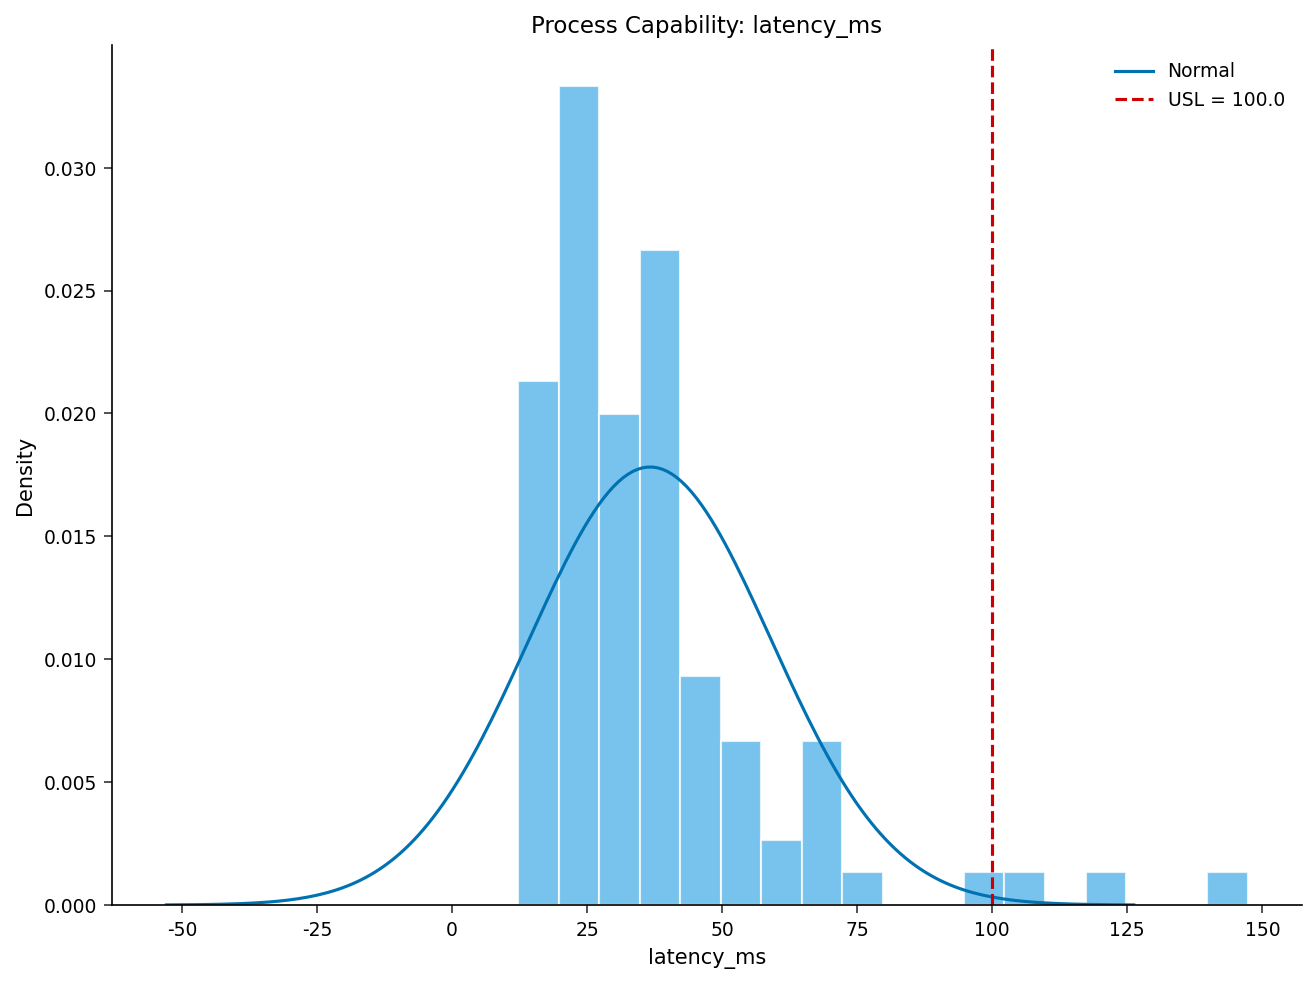

In [6]:
/* --------------------------------------------------------
   Kapabilitetsindeks pr. PoP. BY-gruppernes rækkefølge er
   EDGE-A derefter EDGE-B, så det første indekspar tilhører
   EDGE-A og det andet EDGE-B.
   -------------------------------------------------------- */
PROCEDURE SORTER data=work.lat2;
    EFTER pop_id;
KØR;

PROCEDURE capability data=work.lat2 NOPRINT;
    EFTER pop_id;
    spec usl=100;
    VARIABEL latency_ms;
    HISTOGRAM latency_ms / lognormal;
    ODS UDDATA CapabilityIndices=work.cap_by_pop;
KØR;

PROCEDURE UDSKRIV data=work.cap_by_pop noobs;
    TITEL "Kapabilitetsindeks efter PoP (EDGE-A derefter EDGE-B)";
KØR;

### Fortolkning

De to PoP'er fortæller modsatte kapabilitetshistorier ud fra den samme SLA. **EDGE-A** holder et gennemsnit på **27.38 ms** med en 95. percentil på **42.63 ms** og et maksimum på **43.17 ms** — aldrig tæt på grænsen — og opnår en **Cpk på 2.81**, langt over acceptgrænsen på 1.33. **EDGE-B** kører varmere: et gennemsnit på **45.94 ms**, en 95. percentil på **114.92 ms** og et maksimum på **147.28 ms**, med prober rutinemæssigt forbi SLA'en. Dens **Cpk falder til 0.65**, et godt stykke under 1.0, hvilket markerer den som **ikke kapabel** — procescentret er for tæt på (og dens hale langt forbi) grænsen på 100 ms.

For et netværksdriftsteam er indekset et handlingsanvisende triagesignal: EDGE-A overholder kravene og kræver ingen handling, mens EDGE-B kræver kapacitetsudvidelse eller routingændringer, før den kan opfylde SLA'en. Den lognormale tilpasning betyder noget her — en normal model ville undervurdere den halerisiko, der driver EDGE-B's dårlige kapabilitet. Enkelt-PoP-analysen tidligere (Cpk = 1.42) ligger mellem disse to og illustrerer hele spektret fra fejlende til komfortabelt kapabel, som en ensidig latens-SLA producerer.

---

In [7]:
/* --------------------------------------------------------
   Eksportér kapabilitetsindeksene pr. PoP til et NOC-dashboard.
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.cap_by_pop
    OUTFILE='edge_pop_capability.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.cap_by_pop outfile=edge_pop_capability.csv

NOTE: Exported 4 rows to edge_pop_capability.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>